In [ ]:
import  numpy as np
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
def extract(src):
    df = pd.read_csv(src)
    print(f"Rows: {df.shape[0]},\tColumns: {df.shape[1]}")

    df = df.rename(columns=lambda x: x.replace(" ", ""))
    return df

In [ ]:
from  google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df =  pd.read_csv(file_name)
print(f"Rows: {df.shape[0]},\tColumns: {df.shape[1]}")
print(df)


Saving diabetes.csv to diabetes.csv
Rows: 768,	Columns: 9
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0      

In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


/tmp/ipykernel_7346/4193600247.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2")


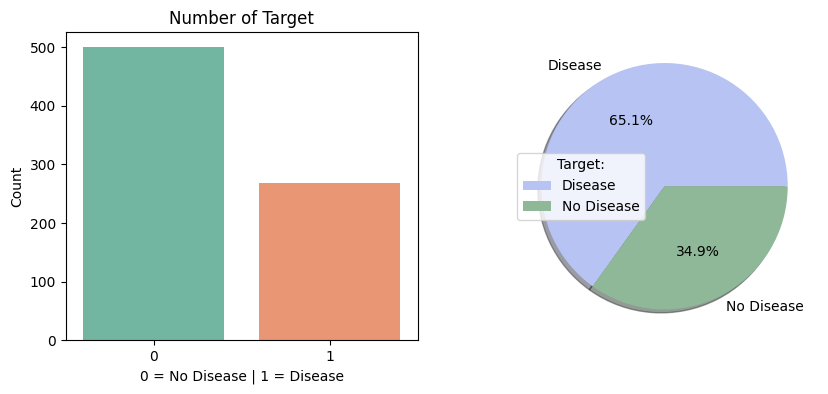

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x="Outcome", data=df, palette="Set2")
plt.title("Number of Target")
plt.xlabel("0 = No Disease | 1 = Disease")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
target_counts = df['Outcome'].value_counts()
plt.pie(target_counts.values, labels=["Disease", "No Disease"], shadow=True, autopct="%1.1f%%", colors=["#B7C3F3", "#8EB897"])
plt.legend(title="Target:")

plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


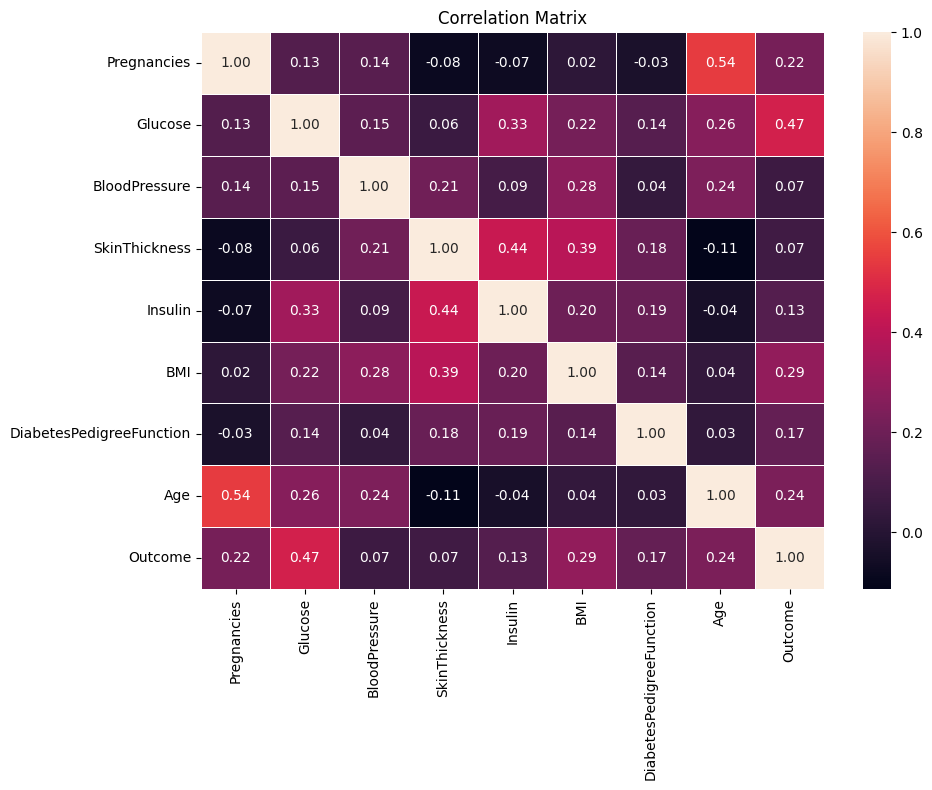

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap='rocket',   # 🔥 purple/pink theme (same as confusion matrix)
            linewidths=0.5,
            linecolor='white')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
x = df.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [ ]:
y=df['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=20)

In [ ]:
xtrain.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
446,1,100,70,25.3,0.658,28
260,3,191,130,30.9,0.299,34
570,3,78,0,32.5,0.270,39
590,11,111,0,46.8,0.925,45
30,5,109,0,36.0,0.546,60


In [ ]:
ytrain.head()

,Outcome
446,0
260,0
570,0
590,1
30,0


In [ ]:
model = LogisticRegression()
model.fit(xtrain,ytrain)

LogisticRegression()

In [ ]:
predictions = model.predict(xtest)

In [ ]:
predictions

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [ ]:
ytest.head()

,Outcome
143,1
14,1
504,0
557,0
736,0


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
acc = accuracy_score(predictions,ytest)
cm = confusion_matrix(predictions,ytest)

In [ ]:
acc ,cm



(0.7727272727272727,
 array([[91, 25],
        [10, 28]]))

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
x = df.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [ ]:
y=df['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
x = df.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [ ]:
y=df['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score # Updated imports for classification metrics

# Function to evaluate classification model
def evaluate_model(model, xtest, ytest):
    pred = model.predict(xtest)

    # Calculate classification metrics
    accuracy = accuracy_score(ytest, pred)
    f1 = f1_score(ytest, pred)
    precision = precision_score(ytest, pred) # Calculate precision

    return accuracy, f1, precision # Return three classification metrics

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize results list to store model performances
results = []

# Evaluate the Logistic Regression model (at this point, 'model' refers to LogisticRegression)
acc_lr, f1_lr, prec_lr = evaluate_model(model, xtest, ytest)
results.append(["Logistic Regression", acc_lr, f1_lr, prec_lr])

# Define and train a KNeighborsClassifier to resolve the NameError for 'mdl'
# Using a default n_neighbors value as the optimal one is calculated in a later cell.
mdl = KNeighborsClassifier(n_neighbors=5) # You can adjust n_neighbors if desired
mdl.fit(xtrain, ytrain)

# Evaluate the KNeighborsClassifier model
acc_knn, f1_knn, prec_knn = evaluate_model(mdl, xtest, ytest)
results.append(["KNN (Default n=5)", acc_knn, f1_knn, prec_knn])

In [ ]:
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score", "Precision"])

print(df_results)

                 Model  Accuracy  F1-Score  Precision
0  Logistic Regression  0.772727  0.615385   0.736842
1    KNN (Default n=5)  0.740260  0.591837   0.644444


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2)

In [ ]:
model = RandomForestClassifier()
model.fit(xtrain,ytrain)

RandomForestClassifier()

In [ ]:
pr = model.predict(xtest)

In [ ]:
ass = accuracy_score(ytest, pr)
print("Accuracy:", ass)

cm = confusion_matrix(ytest, pr)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(ytest, pr))

Accuracy: 0.7922077922077922
Confusion Matrix:
 [[86  8]
 [24 36]]

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.91      0.84        94
           1       0.82      0.60      0.69        60

    accuracy                           0.79       154
   macro avg       0.80      0.76      0.77       154
weighted avg       0.80      0.79      0.78       154



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
from sklearn.metrics import classification_report

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
x = df.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [ ]:
y=df['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2)

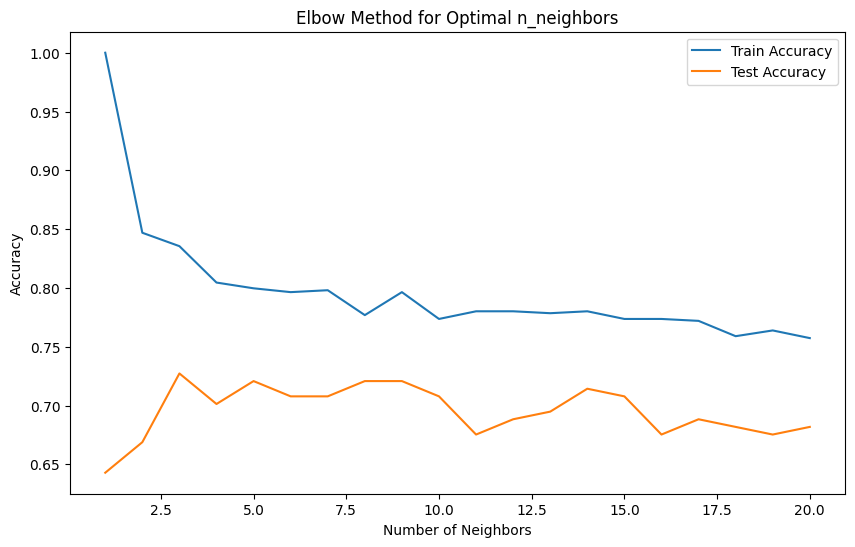

In [ ]:
import numpy as np
neighbors = np.arange(1, 21)
train_accuracy = []
test_accuracy = []

for n in neighbors:
    mdl = KNeighborsClassifier(n_neighbors=n)
    mdl.fit(xtrain, ytrain)
    train_accuracy.append(mdl.score(xtrain, ytrain))
    test_accuracy.append(mdl.score(xtest, ytest))
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracy, label="Train Accuracy")
plt.plot(neighbors, test_accuracy, label="Test Accuracy")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Optimal n_neighbors")
plt.legend()
plt.show()


In [ ]:

optimal_n_neighbors = neighbors[np.argmax(test_accuracy)]
print(f"Optimal n_neighbors: {optimal_n_neighbors}")


Optimal n_neighbors: 3


In [ ]:
mdl_opt = KNeighborsClassifier(n_neighbors=optimal_n_neighbors)
mdl_opt.fit(xtrain, ytrain)
acc_knn_opt, f1_knn_opt, prec_knn_opt = evaluate_model(mdl_opt, xtest, ytest)

results_updated = [res for res in results if not res[0].startswith("KNN")] # Filter out any previous KNN entries
results_updated.append([f"KNN (Optimized n={optimal_n_neighbors})", acc_knn_opt, f1_knn_opt, prec_knn_opt])
df_results_updated = pd.DataFrame(results_updated, columns=["Model", "Accuracy", "F1-Score", "Precision"])
print("\nUpdated Model Comparison:")
print(df_results_updated.sort_values(by="Accuracy", ascending=False))


Updated Model Comparison:
                 Model  Accuracy  F1-Score  Precision
0  Logistic Regression  0.772727  0.615385   0.736842
1  KNN (Optimized n=3)  0.727273  0.611111   0.660000


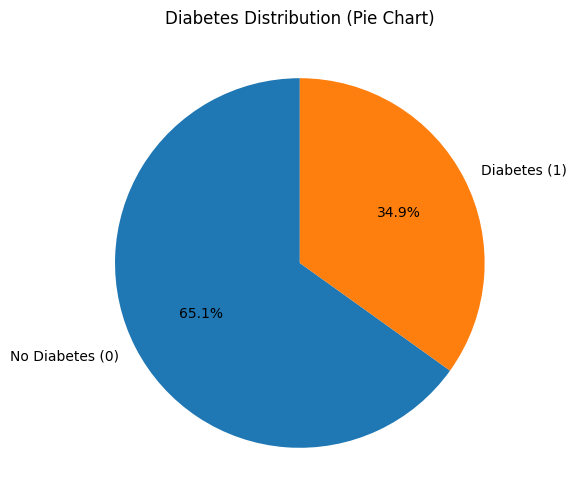

In [ ]:
import matplotlib.pyplot as plt
counts = df['Outcome'].value_counts()
labels = ['No Diabetes (0)', 'Diabetes (1)']
plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Diabetes Distribution (Pie Chart)")
plt.show()

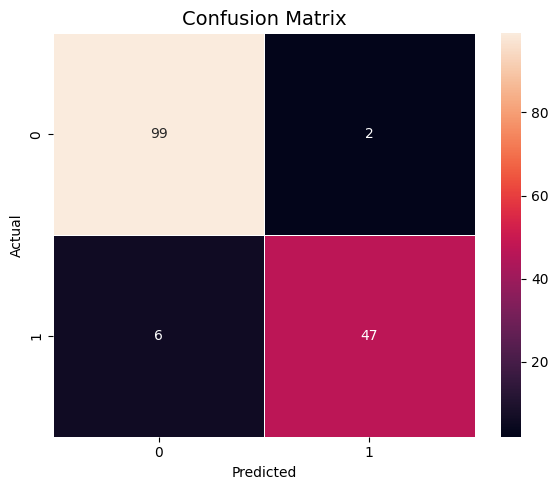

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values
cm = np.array([[99, 2],
               [6, 47]])

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='rocket',   # dark purple → pink gradient
            cbar=True,
            linewidths=0.5,
            linecolor='white',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

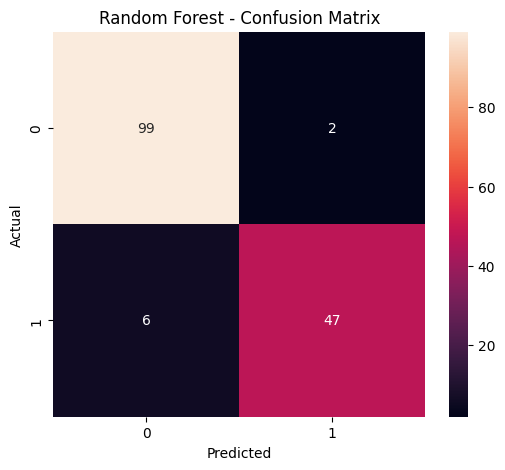

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values from your image
cm = np.array([[99, 2],
               [6, 47]])

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='rocket',   # 🔥 same dark purple/pink style
            cbar=True,
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

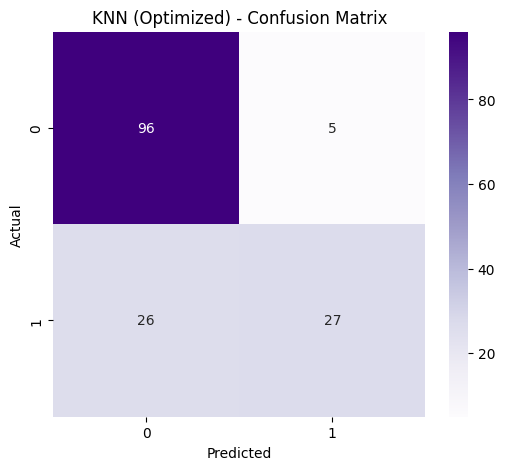

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your confusion matrix values
cm = np.array([[96, 5],
               [26, 27]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.title("KNN (Optimized) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()